<a href="https://colab.research.google.com/github/SAYildirim/dnn-comms/blob/main/demodulator.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Optimum Receivers for Additive White Gaussian Noise (AWGN) Channels
The AWGN channel is mathematically described by the relation
\begin{equation}
r(t) = s_m(t) + n(t),
\end{equation}
where $s_m(t)$ is one of M possible transmitted signal; $n(t)$ is a sample waveform of a zero-mean white Gaussian noise process with power spectral density of $\frac{N_0}{2}$; and $r(t)$ is the received waveform.

The receiver observes the received signal $r(t)$ and makes the optimal decision about which message $m, 1 \leq m \leq M$, was transmitted based on its observation. The optimal decision is defined as a decision rule which results in minimum error probability, i.e., one that minimizes the probability of disagreement between the transmitted message $m$ and the detected message $\hat{m}$ given by
\begin{equation}
P_e = P \left[\hat{m} \neq m\right].
\end{equation}

As the AWGN channel model isolates the effect of noise from the effects of other channel impairments on the communication systems' performance, it is often regarded as too simplistic for direct use in complex, practical applications. However,

# The Connection to Vector Gaussian Channels
It is known that each waveform $s_m(t)$ can be represented by a vector $\mathbf {s} \in \mathbb{C}^N$ using $N$ orthonormal bases $\phi_j(t)$, $1 \leq j \leq N$. Moreover, it is also known that any orthonormal basis can be used for expansion of a zero-mean white Gaussian process, and the resulting coefficients of expansion will be independent identically distirbuted (iid) zero mean complex Gaussian random variables with variance $\frac{N_0}{2}$. Consequently, $\phi_j(t)$, $1 \leq j \leq N$, when extended appropriately, can be used for expansion of the noise process $n(t)$. This establishes a connection between waveform channels and vector channels, which is easier to analyze.

For the rest of this work, we will be using the following vector channel model
\begin{equation}
\mathbf{r} = \mathbf{s}_m + \mathbf{n}.
\end{equation}
where all vectors are $N$-dimensional complex vectors. The message is chosen with probability mass function (pmf) $P_M(m)$ from the set of possible messages $\{1,2,\cdots,M\}$. The noise components $n_j$, $1\leq j \leq N$, are iid zero-mean, complex Gaussian random variables each distributed according to $\mathcal{N}(0,\frac{N_0}{2})$. Therefore, the joint probability density function (pdf) of the noise vector $\mathbf{n}$ is given by
\begin{equation}
p_N(\mathbf{n}) = \left(\frac{1}{\pi N_0}\right)^{2N} e^{-\frac{\| \mathbf{n} \|^2}{N_0}}.
\end{equation}

Observing the $N$-dimensional vector $\mathbf{r}$, the receiver decides which messages was transmitted using a decision rule $g(\mathbf{r})$, which is defined as a map from the set of N-dimensional complex numbers to the set of messages $\mathcal{M}$, as follows
\begin{equation}
g(\mathbf{r}) : \mathbb{C}^N \rightarrow \{ 1,2,\cdots, M\}.
\end{equation}
# The Optimal Decision Rule
If the receiver decides that $\hat{m}$ was transmitted, then the probability of correct decision, given $\mathbf{r}$ is received, is given by
\begin{align}
P\left[\mathrm{correct\, decision}\right] &= \int P\left[\mathrm{correct\, decision} | \mathbf{r} \right] p(\mathbf{r}) d\mathbf{r}\\
&= \int P\left[\hat{m} | \mathbf{r}\right]  p(\mathbf{r}) d\mathbf{r}
\end{align}

The optimal decision rule is the one that minimizes the error probability or, equivalenty, maximizes the probability of correct decision. Since $p(\mathbf{r})$ is nonnegative for any $\mathbf{r} \in \mathbb{C}^N$, the correct decision probability is maximized if a posteriori probability $P[\hat{m}|\mathbf{r}]$ is maximized for each $\mathbf{r}$. In other words,
\begin{equation}
\hat{m}_{\mathrm{MAP}} = g_{\mathrm{opt}}(\mathbf{r}) = \arg \max_{m\in\mathcal{M}} P[m|\mathbf{r}] = \arg \max_{m\in\mathcal{M}} P[m] P[\mathbf{r}|\mathbf{s}_m].
\end{equation}
This is called the maximum a posteriori (MAP) decision rule. If the transmitter selects any message equally likely for transmission, the MAP decision rule boils down to the maximum likelihood decision rule
\begin{equation}
\hat{m}_{\mathrm{ML}} = \arg \max_{m\in\mathcal{M}} P[\mathbf{r}|\mathbf{s}_m].
\end{equation}

Applying the optimal decision rule, we can write the MAP detector for AWGN vector channels as
\begin{align}
\hat{m} &=  \arg \max_{m\in\mathcal{M}} P[m] P[\mathbf{r}|\mathbf{s}_m] \\
&= \arg \max_{m\in\mathcal{M}} P[m] p_N(\mathbf{r}-\mathbf{s}_m) \\
&=  \arg \max_{m\in\mathcal{M}} P[m]  \left(\frac{1}{\pi N_0}\right)^{2N} e^{-\frac{\| \mathbf{r}-\mathbf{s}_m \|^2}{N_0}} \\
&= \arg \max_{m\in\mathcal{M}} \log P[m] - \frac{\| \mathbf{r}-\mathbf{s}_m \|^2}{N_0} \\
&= \arg \max_{m\in\mathcal{M}} \frac{N_0}{2}\log P[m] - \frac{1}{2} \| \mathbf{r}-\mathbf{s}_m \|^2 \\
&= \arg \max_{m\in\mathcal{M}} \frac{N_0}{2}\log P[m] - \frac{1}{2} \left( \| \mathbf{r}\|^2 + \| \mathbf{s}_m \|^2 - 2\mathbf{r}^T\mathbf{s}_m\right) \\
&= \arg \max_{m\in\mathcal{M}} \eta_m + \mathbf{r}^T\mathbf{s}_m
\end{align}
where $\eta_m$ is defined as
\begin{equation}
\eta_{m} =  \frac{N_0}{2}\log P[m] - \frac{1}{2} \|\mathbf{s}_m \|^2.
\end{equation}

# A Shallowest Neural Network is an Optimal Detector in AWGN

Our conjecture is that a single layer of simple, multilayer perceptron (MLP) network can optimally detect messages in AWGN channels. In order to see this, we design a single layer MLP network that takes noisy complex received symbols $\mathbf{r}$ as two-dimensional inputs at a time.

For convention, the real and imaginary parts of $\mathbf{r}$ constitute the first and second dimensions of the inputs, respectively. The network consists of $M$ neurons, each of which stands for a symbol $\mathbf{s}_m$ in the signal constellation. The input output relationship of this network can be written as
\begin{equation}
y =  \sigma \left(\mathbf{W} \mathbf{r} + \mathbf{b} \right)
\end{equation}
where $\mathbf{W}$ stores weights of the connections between input neurons and $M$ hidden neurons, and $\mathbf{b}$ is called the bias vector. The function $\sigma(\cdot)$ is the nonlinear activation function which we will elaborate later.

First, we would like to highlight the striking similarity between the arguments of the optimal MAP detector given previously and the function $\sigma(\cdot)$

Clearly, choosing the network parameters carefully, i.e.,  the $m$-th rows of $\mathbf{W}$ as $\mathbf{w}_m = \mathbf{s}_m$ and of $\mathbf{b}$ as $b_m = \eta_m$, one can recover MAP detector with this network without even need for any training. Thus, we ask the following burning question: what do we gain by using NNs?

Well, as we mentioned in the beginning, this problem is a simple toy example that we demonstrate the NNs' capability to infer meaningful information from a collection of data which is referred to as "training data". Due to the simple nature of the problem, it will facilitate us to build a solid understanding about how a NN infers information from data,  allow us to track the evolution of learning, and  to validate whether the inferred information converges to the optimal behaviour seen in the conventional communication blocks.

There are various activation functions available in the literature. A common approach is to try several activation functions, and pick the one that gives the best results. However, we would like to depart from this approach, instead, we will try to associate the choices of the network parameters, such as number of neurons, type of activation function, with what the optimal solutions suggest as they are available. From this perspective, we are interested in explainable-AI, and wil follow this approach for the rest of the work.

Now, going to back to the nonlinear activation function $\sigma(\cdot)$, the only remaning






# Yapilabilecekler


1.   Farkli fading senaryolarinda kanalda ne oluyor?

*   Slow Fading katsayisi h biliniyor -> training ve teste ayni h
*   Block Fading katsayisi h kestirilmis ve veriliyor -> trainingde degisen h'ler, test'te de degisiyor. (Vakit olursa)
*   Fast fading -> her sembolde degisiyor

2.  Training datasindaki SNR degisirse network ne ogreniyor -> softmax ve sigmoid karsilastirilabilir.

3. Equalization problemi -> Memory utilize eden bir network gerekiyor.

*   Modulasyon ve SNR sabit ve biliniyor (orn. 16-QAM ve 13 dB), input ->
pilot sembolleri, sabit bir h katsayisi kestirilecek.-> NN optimal cozum olan BLUE'ya yakinsamasini bekliyoruz.
*   Pilotlar uzerinden yavas degisen kanali kestir ve track et. -> Adaptive Equalizer
*   Data random olusturuldu -> sabit bit kanali h 'i kestiricek ->  Generalized ML equalizer -> Data-Driven cozum mle ne kadar yakin?   

3. Joint modulasyon tespiti ve kod cozumu mumkun mu?

# Duzeltilecekler

1.   Teorik SER hesabindaki hata
2.   Gurultu uretirken kullanilan EBN0, EsN0 snr_dB arasindaki uyumsuzluk

1. Florida Uni'deki tezi at.
2. The Agentic AI Manual'i at.

In [ ]:
import numpy as np
import sys, datetime, os
import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim.lr_scheduler import ReduceLROnPlateau, CyclicLR
from torch.utils.data import TensorDataset, DataLoader
from torch.utils.tensorboard import SummaryWriter
import matplotlib.pyplot as plt
from scipy.special import erfc
from scipy.spatial.distance import cdist

# ---------- Parameters ----------
mod_type = 'qam'
M = int(4)                 # modulation order
n_symbols = int(4e5)        # total symbols to generate
train_frac = 0.90           # fraction for training
valid_frac = 0.05           # fraction for validation
snr_db_train = 20.0         # training SNR in dB (Eb/N0-like)
snr_db_test = np.arange(start=-4,stop=12, step = 2) # range of testing SNR in dB
batch_size = 100
n_epochs = 50
lr = 1e-3                   # learning rate
patience = 20
delta = 1e-6
log_step = 25
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

logs_base_dir = "runs"
os.makedirs(logs_base_dir, exist_ok=True)

In [ ]:
# ---------- Helper functions ----------
def modulate(symbols,mod_type=None,M=0):
    if mod_type==None:
        raise ValueError('Invalid value for mod_type')
    if (M<2) or ((M & (M -1))!=0): #if M not a power of 2
        raise ValueError('M should be a power of 2')
    func_dict = {'psk': psk_modulation,'qam':qam_modulation}
    return func_dict[mod_type.lower()](symbols, M) #call appropriate function

def psk_modulation(symbols, M):
    # M-PSK constellation generation
    m = np.arange(0,M) #all information symbols m={0,1,...,M-1}
    I = 1/np.sqrt(2)*np.cos(m/M*2*np.pi)
    Q = 1/np.sqrt(2)*np.sin(m/M*2*np.pi)
    constellation = I + 1j*Q #reference constellation
    return constellation[symbols]

def qam_modulation(symbols, M):
    # M-QAM constellation generation
    if (M==1) or (np.mod(np.log2(M),2)!=0): # M not a even power of 2
      raise ValueError('Only square MQAM supported. M must be even power of 2')

    n = np.arange(0,M) # Sequential address from 0 to M-1 (1xM dimension)
    a = np.asarray([x^(x>>1) for x in n]) # Binary code to Gray code
    D = np.sqrt(M).astype(int) #Dimension of K-Map - N x N matrix
    a = np.reshape(a,(D,D)) # NxN gray coded matrix
    oddRows=np.arange(start = 1, stop = D ,step=2) # identify alternate rows
    a[oddRows,:] = np.fliplr(a[oddRows,:]) #Flip rows - KMap representation
    nGray=np.reshape(a,(M)) # reshape to 1xM - Gray code walk on KMap
    #Construction of ideal M-QAM constellation from sqrt(M)-PAM
    (x,y)=np.divmod(nGray,D) #element-wise quotient and remainder
    Ax=2*x+1-D # PAM Amplitudes 2d+1-D - real axis
    Ay=2*y+1-D # PAM Amplitudes 2d+1-D - imag axis
    constellation = Ax+1j*Ay
    return constellation[symbols]

def iqDetector(symbols, M):
    # Minimum distance detector: optimal for coherent mods in awgn
    m = np.arange(0,M) #all information symbols m={0,1,...,M-1}
    I = 1/np.sqrt(2)*np.cos(m/M*2*np.pi)
    Q = 1/np.sqrt(2)*np.sin(m/M*2*np.pi)
    XA = np.column_stack((np.real(symbols),np.imag(symbols)))
    XB = np.column_stack((I,Q))
    d = cdist(XA,XB,metric='euclidean') #compute pair-wise Euclidean distances

    return np.argmin(d, axis=1)

def psk_bitmap(symbols, M):
    Exp = (2**np.arange(np.log2(M))).astype(int)
    return ((symbols.astype(int).reshape(-1,1) & Exp)!=0).astype(int)[:, ::-1]

def psk_intmap(bits):
    b2i = 2**np.arange(bits.shape[0]-1, -1, -1)
    return (bits*b2i).sum(axis=1)

def bpsk_map(bits):
    # Map bits {0,1} -> symbols {-1,+1}
    return 2 * bits - 1

def awgn_iq(symbols_iq, snr_db):
    # symbols_iq: shape (N, 2) real (I,Q)
    # compute noise std from SNR (assuming symbol power = mean(|s|^2))
    ps = np.mean(np.sum(symbols_iq**2, axis=1))
    snr_linear = 10 ** (snr_db / 10.0)
    sigma = ps / snr_linear
    N0 = sigma / 2 # per-dimension (I and Q) variance
    noise = np.sqrt(N0/2) * np.random.randn(*symbols_iq.shape)
    return symbols_iq + noise

def ser_awgn(EbN0dBs,mod_type=None,M=0,coherence=None):
    if mod_type==None:
        raise ValueError('Invalid value for mod_type')
    if (M<2) or ((M & (M -1))!=0): #if M not a power of 2
        raise ValueError('M should be a power of 2')
    func_dict = {'psk': psk_awgn,'qam':qam_awgn}
    gamma_s = np.log2(M)*(10**(EbN0dBs/10))
    if mod_type.lower()=='fsk': #call appropriate function
        return func_dict[mod_type.lower()](M,gamma_s,coherence)
    else:
        return func_dict[mod_type.lower()](M,gamma_s) #call appropriate function

def psk_awgn(M,gamma_s):
    gamma_b = gamma_s/np.log2(M)
    if (M==2):
        SERs = 0.5*erfc(np.sqrt(2*gamma_b))
    elif M==4:
        Q = 0.5*erfc(np.sqrt(gamma_b))
        SERs = 2*Q-Q**2
    else:
        SERs = erfc(np.sqrt(gamma_s)*np.sin(np.pi/M))
    return SERs

def qam_awgn(M,gamma_s):
    if (M==1) or (np.mod(np.log2(M),2)!=0): # M not a even power of 2
        raise ValueError('Only square MQAM supported. M must be even power of 2')
    SERs = 1-(1-(1-1/np.sqrt(M))*erfc(np.sqrt(3/2*gamma_s/(M-1))))**2
    return SERs



# ---------- Single-layer model ----------
class SingleLayerDemod(nn.Module):
    def __init__(self, M):
        super().__init__()
        # Input  2 -> in-phase and quadrature components
        # Output M -> M logits -> softmax gives probability of symbols
        self.M = M
        self.linear = nn.Linear(2, self.M, bias=True)

    def forward(self, x):
        # x shape: (batch, 2)
        out = self.linear(x)  # (batch,2)
        prob = torch.softmax(out, dim=1)
        return prob

# Custom EarlyStopping class from scratch
class EarlyStopping:
    def __init__(self, patience=5, delta=0.001, path='checkpoint.pt', verbose=True):
        self.patience = patience
        self.delta = delta
        self.path = path
        self.verbose = verbose
        self.best_loss = None
        self.no_improvement_count = 0
        self.stop_training = False

    def check_early_stop(self, val_loss):
        if self.best_loss is None or val_loss < self.best_loss - self.delta:
            self.best_loss = val_loss
            self.no_improvement_count = 0
            # Save checkpoint if improvement observed
            torch.save(model.state_dict(), self.path)
            if self.verbose:
                print(f"Model improved; checkpoint saved at loss {val_loss:.6f}")
        else:
            self.no_improvement_count += 1
            if self.no_improvement_count >= self.patience:
                self.stop_training = True
                if self.verbose:
                    print("Early stopping triggered.")

In [ ]:
# ---------- Generate dataset ----------
## Random bits
#bits = np.random.randint(0, 2, size=(n_symbols,)).astype(np.float32)
## Map to BPSK symbols on I axis; Q = 0
#symbols = bpsk_map(bits)  # shape (n_symbols,)
#symbols_iq = np.stack([symbols, np.zeros_like(symbols)], axis=1)  # (N,2)

# Random symbols
symbols = np.random.randint(0, M, size=(n_symbols,)).astype(int)
modulated_symbols = modulate(symbols,mod_type,M)
symbols_iq = np.stack([np.real(modulated_symbols),
                       np.imag(modulated_symbols)], axis=1)  # (N,2)
bits    = psk_bitmap(symbols, M)

# Split train/test
n_train = int(n_symbols * train_frac)
n_valid = int(n_symbols * valid_frac)
n_test  = n_symbols - n_train - n_valid

train_x = awgn_iq(symbols_iq[:n_train], snr_db_train)
train_y = symbols[:n_train]
# re-noise validation partition (fresh noise)
valid_x = awgn_iq(symbols_iq[n_train:n_train+n_valid], 3)
valid_y = symbols[n_train:n_train+n_valid]

# Convert to PyTorch tensors
train_x_t = torch.from_numpy(train_x).float()
train_y_t = torch.from_numpy(train_y).float().long()  # shape (N,1)
valid_x_t = torch.from_numpy(valid_x).float()
valid_y_t = torch.from_numpy(valid_y).float().long()

train_ds = TensorDataset(train_x_t, train_y_t)
valid_ds = TensorDataset(valid_x_t, valid_y_t)
train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
valid_loader = DataLoader(valid_ds, batch_size=batch_size, shuffle=False)

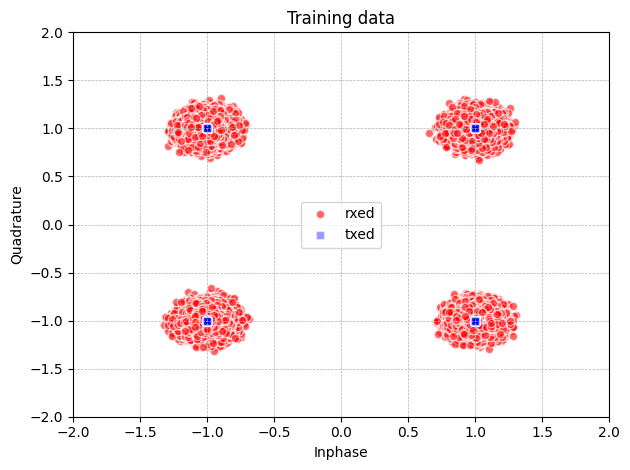

In [ ]:
fig, ax = plt.subplots()
I, Q = symbols_iq[:n_train][:,0], symbols_iq[:n_train][:,1]
ax.scatter(train_x[:,0], train_x[:,1], c='red', label='rxed', alpha=0.6,
           edgecolor='white')
ax.scatter(I, Q, c='blue',marker='s',label='txed',alpha=0.4,edgecolor='white')
ax_lim = np.ceil(1.1*np.max([I, Q]))
plt.ylim(-ax_lim, ax_lim)
plt.xlim(-ax_lim, ax_lim)
plt.title('Training data')
plt.xlabel('Inphase')
plt.ylabel('Quadrature')
plt.legend(loc="center")
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.tight_layout()
plt.show()


In [ ]:
#%load_ext tensorboard
#%tensorboard --logdir {logs_base_dir}

In [ ]:
model = SingleLayerDemod(M).to(device)

writer = SummaryWriter()

# Initialize weights sensibly (small)
nn.init.normal_(model.linear.weight, mean=0.0, std=0.1)
nn.init.constant_(model.linear.bias, 0.0)

# Loss and optimizer
criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=lr)

# Reduce LR by a factor of 0.1 if loss doesn’t improve for "patience" epochs
scheduler = ReduceLROnPlateau(optimizer, mode='min',factor=0.1, patience=10)
## Change LR every epoch
#scheduler = CyclicLR(optimizer, base_lr=1e-6, max_lr=1e-2, step_size_up=1,
#                     mode='triangular')

# Initialize early stopping
#early_stopping = EarlyStopping(patience=patience, delta=delta, verbose=True)

# Store parameters for visualization
best_loss = np.inf
images = []
# ---------- Training ----------
for epoch in range(1, n_epochs + 1):
    writer.add_scalar('Learning/rate', optimizer.param_groups[0]['lr'], epoch)
    # Training phase
    model.train()
    step = 0
    epoch_loss = 0.0
    total_train_samples = 0
    for xb, yb in train_loader:
        step += 1
        optimizer.zero_grad()
        xb, yb = xb.to(device), yb.to(device)

        probs = model(xb)
        loss = criterion(probs, nn.functional.one_hot(yb, M).float())
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item() * train_loader.batch_size
        total_train_samples += train_loader.batch_size

        if step % log_step == log_step - 1:
            current_step = epoch * len(train_loader) + step
            avg_batch_loss = epoch_loss / (log_step * train_loader.batch_size)
            writer.add_scalar('Loss/train_batch', avg_batch_loss, current_step)
            writer.flush()

    epoch_loss /= total_train_samples
    scheduler.step(epoch_loss)

    writer.add_scalar('Loss/train_epoch', epoch_loss, epoch)
    writer.flush()

    print(f"Epoch {epoch}/{n_epochs}, Training Loss: {epoch_loss:.6f}")

    if epoch_loss < best_loss:
        best_loss = epoch_loss
        torch.save(model.state_dict(), 'best_model.pth')

    # Validation phase
    model.eval()
    epoch_loss = 0.0
    correct = 0
    total_val_samples = 0
    with torch.no_grad():
        for xb, yb in valid_loader:
            xb, yb = xb.to(device), yb.to(device)

            probs = model(xb)
            loss = criterion(probs, nn.functional.one_hot(yb, M).float())
            epoch_loss += loss.item() * valid_loader.batch_size

            preds = probs.argmax(dim=1)
            correct += (preds == yb).sum().item()
            total_val_samples += valid_loader.batch_size

    epoch_loss /= total_val_samples
    accuracy = 100.0 * correct / total_val_samples

    writer.add_scalar('Loss/validation', epoch_loss, epoch)
    writer.add_scalar('Accuracy/validation', accuracy, epoch)
    #writer.add_graph(model, valid_loader.dataset.tensors[0])

    weights = model.linear.weight.cpu().detach()
    biases  = model.linear.bias.cpu().detach()
    #writer.add_histogram('Distribution/weights', weights, epoch)
    #writer.add_histogram('Distribution/biases', biases, epoch)
    #writer.add_embedding(weights, global_step=epoch, tag='Constellation/inferred')
    writer.flush()

    print(f"Epoch {epoch}/{n_epochs}, Validation Loss: {epoch_loss:.6f}")

# Close the writer when training is complete
writer.close()
# Load best model checkpoint after early stopping
model.load_state_dict(torch.load('best_model.pth'))

Epoch 1/50, Training Loss: 0.128808
Epoch 1/50, Validation Loss: 0.129576
Epoch 2/50, Training Loss: 0.062647
Epoch 2/50, Validation Loss: 0.128407
Epoch 3/50, Training Loss: 0.032847
Epoch 3/50, Validation Loss: 0.139039
Epoch 4/50, Training Loss: 0.017533
Epoch 4/50, Validation Loss: 0.153881
Epoch 5/50, Training Loss: 0.009619
Epoch 5/50, Validation Loss: 0.170264
Epoch 6/50, Training Loss: 0.005471
Epoch 6/50, Validation Loss: 0.187102
Epoch 7/50, Training Loss: 0.003218
Epoch 7/50, Validation Loss: 0.203959
Epoch 8/50, Training Loss: 0.001962
Epoch 8/50, Validation Loss: 0.220232
Epoch 9/50, Training Loss: 0.001240
Epoch 9/50, Validation Loss: 0.235860
Epoch 10/50, Training Loss: 0.000811
Epoch 10/50, Validation Loss: 0.250822
Epoch 11/50, Training Loss: 0.000548
Epoch 11/50, Validation Loss: 0.264851
Epoch 12/50, Training Loss: 0.000382
Epoch 12/50, Validation Loss: 0.278349
Epoch 13/50, Training Loss: 0.000275
Epoch 13/50, Validation Loss: 0.290970
Epoch 14/50, Training Loss: 0.

<All keys matched successfully>

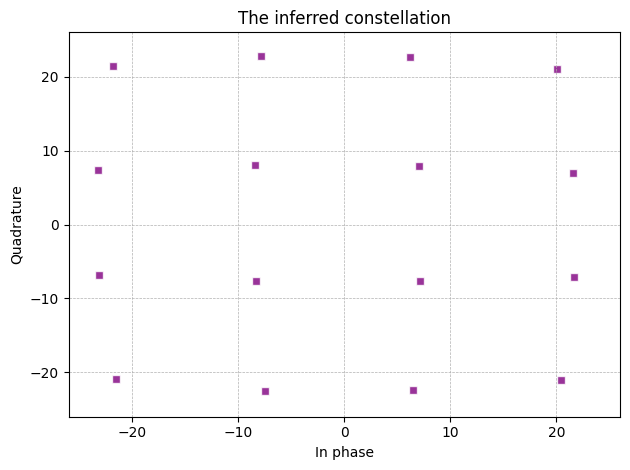

In [ ]:
# The model weights correspond to the inferred constellation
I = model.linear.weight.cpu().detach().numpy()[:,0]
Q = model.linear.weight.cpu().detach().numpy()[:,1]


# Plot the inferred constellation
plt.figure()
plt.scatter(I, Q, c='purple', label='Weights', marker='s', alpha=0.8,
            edgecolor='white')
ax_lim = np.ceil(1.1*np.max([I, Q]))
plt.ylim(-ax_lim, ax_lim)
plt.xlim(-ax_lim, ax_lim)
plt.title('The inferred constellation')
plt.xlabel('In phase')
plt.ylabel('Quadrature')
#plt.legend(loc="center")
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.tight_layout()
plt.show()



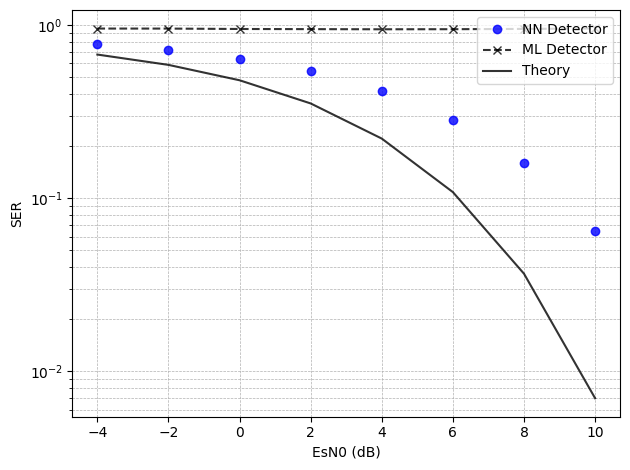

In [ ]:
# ---------- Final evaluation ----------
acc_final, SER_theory, detected = [], [], []
for j,snr_db in enumerate(snr_db_test):

  test_x = awgn_iq(symbols_iq[n_train+n_valid:], snr_db)  # re-noise test partition (fresh noise)
  test_y = symbols[n_train+n_valid:]

  # Convert to PyTorch tensors
  test_x_t = torch.from_numpy(test_x).float()
  test_y_t = torch.from_numpy(test_y).float().long()

  model.eval()
  with torch.no_grad():
      xb,yb = test_x_t.to(device), test_y_t.to(device)

      probs = model(xb)
      preds = probs.argmax(dim=1)
      acc_final.append((preds == yb).float().mean().item())

  #print(f"Final test accuracy: {acc_final[-1]*100:.2f}%")
  SER_theory.append(ser_awgn(snr_db,mod_type,M))
  detected.append(1-(iqDetector(xb[:,0] + 1j*xb[:,1], M) == yb).float().mean().item())
## Show some example predictions (first 10)
#examples = 10
#with torch.no_grad():
#    ex_x = xb[:examples].cpu().numpy()
#    ex_y = yb[:examples].cpu().numpy().flatten()
#    ex_p = probs[:examples].cpu().numpy().flatten()
#    ex_pred = preds[:examples].cpu().numpy().flatten()
#
#print("\nExample (I, Q) | true_bit -> prob -> pred_bit")
#for i in range(examples):
#    i_val, q_val = ex_x[i]
#    print(f"({i_val: .3f}, {q_val: .3f}) | {int(ex_y[i])} -> {ex_p[i]:.3f} -> {int(ex_pred[i])}")

# Plot the probability of symbol error
fig, ax = plt.subplots()
ax.semilogy(snr_db_test, 1-np.array(acc_final), 'o', c='blue',alpha=0.8,
           label='NN Detector')
ax.semilogy(snr_db_test, np.array(detected), 'x', c='black',alpha=0.8,
           linestyle='--', label='ML Detector')
ax.semilogy(snr_db_test, np.array(SER_theory), c='black',alpha=0.8,
            label='Theory')
plt.xlabel('EsN0 (dB)')
plt.ylabel('SER')
plt.legend(loc="upper right")
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.tight_layout()
plt.show()
